In [1]:
import os
os.chdir('../..')

In [17]:
import selfies as sf
from scipy.spatial.distance import cosine, euclidean
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import polars as pl
from rdkit import DataStructs, Chem
from collections import Counter
from sklearn.mixture import GaussianMixture
from rdkit.Chem import AllChem
from sklearn.manifold import MDS
from umap import UMAP
from src.clusters import ClusterAnalysis
from src.datasets import MaterialsProject
from sklearn.manifold import TSNE
from loguru import logger
from sklearn.preprocessing import StandardScaler
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.core import Composition
import chemiscope
import json

In [3]:
mp = MaterialsProject()
mp.load()
mp.df = mp.df.with_columns(
    pl.col("formula_pretty")
    .map_elements(lambda x: Composition(x).weight, return_dtype=pl.Float64)
    .alias("weight")
)

mp.df

2026-03-10 14:03:36.731 | INFO     | src.datasets:load:658 - Loading cached Parquet data from data/Materials Project/stable_oxides.parquet...


material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,acsf_embedding,soap_embedding,weight
str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,list[f64],list[f64],f64
"""mp-1274279""","""FeO""",-8.19051,-1.481519,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",5.614899,3.102294,5.375696,5.443817,110.556657,91.096992,89.9466,84.988477,8,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]",71.8444
"""mp-19921""","""PbO""",-5.800276,-1.469972,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",8.810225,3.999514,3.999514,5.259816,90.0,90.0,90.0,84.136627,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]",223.1994
"""mp-2097""","""SnO""",-6.108469,-1.629702,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",6.294343,3.813695,3.813695,4.8869133,90.0,90.0,90.0,71.076593,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]",134.7094
"""mp-1692""","""CuO""",-5.466379,-0.942795,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",6.1556,2.879501,2.879545,5.176397,89.806512,89.806349,89.222525,42.916449,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]",79.5454
"""mp-1336""","""PdO""",-5.853748,-0.789826,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",8.117606,3.053604,3.053604,5.371257,90.0,90.0,90.0,50.084274,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]",122.4194
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""mp-24129""","""MnH4(BrO)2""",-5.299537,-1.309259,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.976894,3.963651,6.006202,6.006203,95.912312,96.949439,96.949428,139.885532,9,"[4.619654, 0.736364, … 0.0]","[0.100292, 0.26796, … 0.0]",250.776605
"""mp-23880""","""FeH4(ClO)2""",-5.265791,-1.305381,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.287095,5.714367,5.714367,3.721117,82.486963,82.486963,97.148948,118.187118,9,"[5.545048, 0.773538, … 0.0]","[0.100956, 0.268515, … 0.0]",162.78156
"""mp-23853""","""CoH4(ClO)2""",-5.045306,-1.233407,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.424991,3.603494,5.686069,5.686069,97.465063,96.908777,96.908772,113.58114,9,"[5.775085, 0.776909, … 0.0]","[0.101054, 0.268578, … 0.0]",165.869755


# Determining the Correct Amount of Clusters

In [ ]:
def cluster_determination(df, k_max=15, embedding_col="soap_embedding", save_path=None):
    logger.info(f"Running for {embedding_col}")
    df = df.to_pandas()
    X = np.vstack(df[embedding_col].values)

    ks = range(2, k_max + 1)
    silhouettes = []
    ch_scores = []
    inertias = []

    for k in ks:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X)

        silhouettes.append(silhouette_score(X, labels))
        ch_scores.append(calinski_harabasz_score(X, labels))
        inertias.append(kmeans.inertia_)

    # ----- Plot styling (report quality) -----
    plt.style.use("seaborn-v0_8-whitegrid")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

    fontsize_title = 13
    fontsize_label = 11

    # Silhouette
    axes[0].plot(ks, silhouettes, marker="o", linewidth=2)
    axes[0].set_title("Silhouette Score", fontsize=fontsize_title)
    axes[0].set_xlabel("Number of clusters (k)", fontsize=fontsize_label)
    axes[0].set_ylabel("Score", fontsize=fontsize_label)

    # Calinski-Harabasz
    axes[1].plot(ks, ch_scores, marker="o", linewidth=2)
    axes[1].set_title("Calinski-Harabasz Index", fontsize=fontsize_title)
    axes[1].set_xlabel("Number of clusters (k)", fontsize=fontsize_label)
    axes[1].set_ylabel("Score", fontsize=fontsize_label)

    # Inertia (Elbow)
    axes[2].plot(ks, inertias, marker="o", linewidth=2)
    axes[2].set_title("Inertia (Elbow Method)", fontsize=fontsize_title)
    axes[2].set_xlabel("Number of clusters (k)", fontsize=fontsize_label)
    axes[2].set_ylabel("Inertia", fontsize=fontsize_label)

    fig.suptitle(f"Cluster Evaluation ({embedding_col})", fontsize=14, y=1.02)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return {
        "k": list(ks),
        "silhouette": silhouettes,
        "calinski_harabasz": ch_scores,
        "inertia": inertias
    }

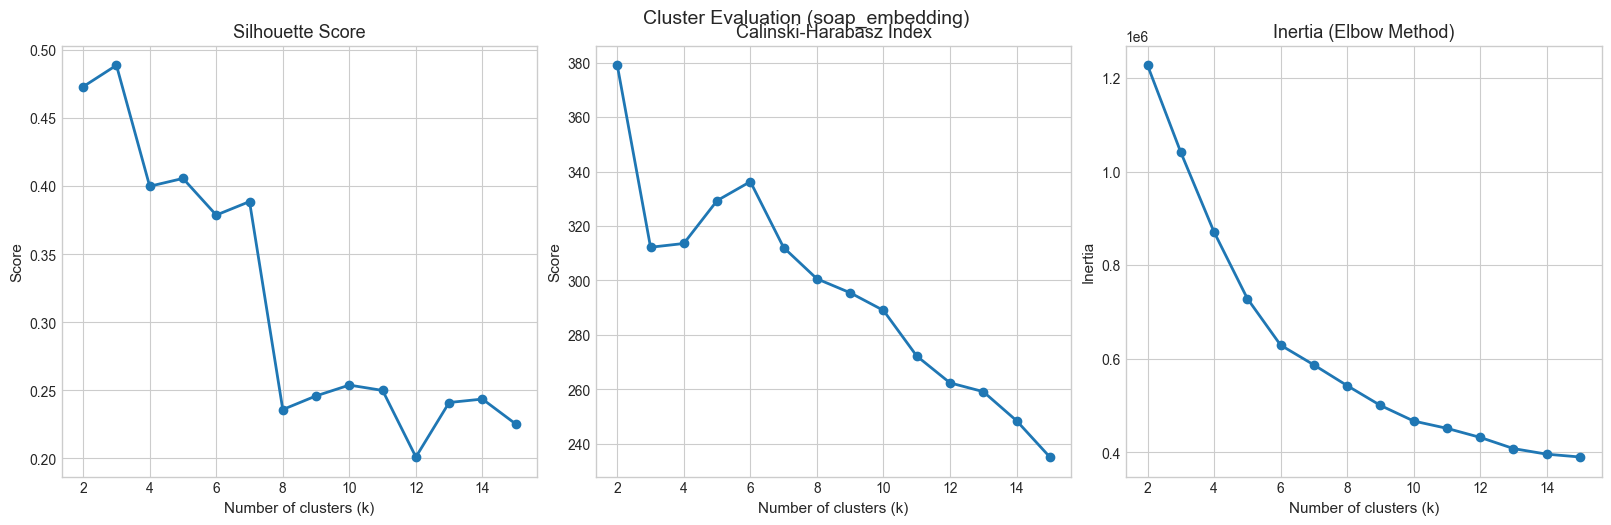

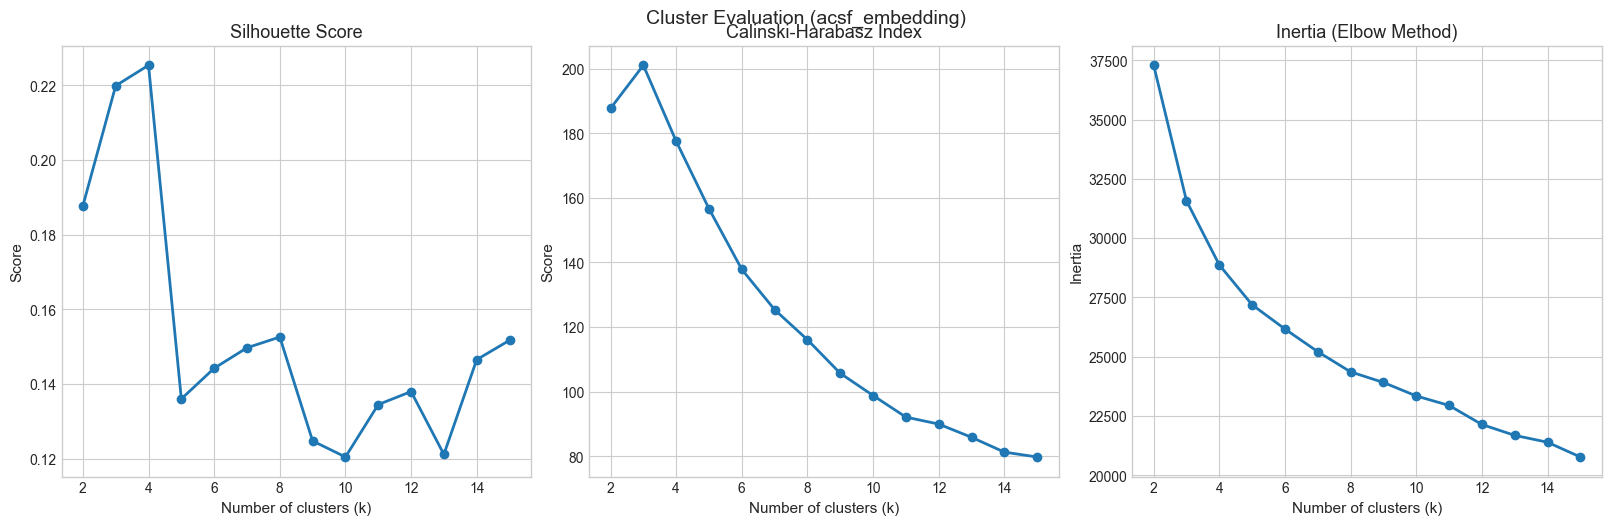

In [5]:
results_soap = cluster_determination(mp.df, k_max=15, embedding_col="soap_embedding")

results_acsf = cluster_determination(mp.df, k_max=15, embedding_col="acsf_embedding")

number of clusters:
- soap: silhouette 3 - interia 6
- acsf: silhoutte 4 - interia 8?

# Clustering on SOAP descriptors

In [27]:
def plot_chemiscope(mp_df, embedding_col="soap_embedding", n_clusters=4):
    # 1. Prepare Data
    df = mp_df.to_pandas()
    X = np.vstack(df[embedding_col].values)

    # 2. Scale and Cluster
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)

    counts = Counter(clusters)
    for i in range(n_clusters):
        print(f"Number of molecules in cluster {i + 1}: {counts[i]}")

    # 3. Dimensionality Reduction (t-SNE)
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
    X_tsne = tsne.fit_transform(X_scaled)

    reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    mds = MDS(n_components=2, random_state=42, normalized_stress='auto')
    X_mds = mds.fit_transform(X_scaled)

    # 4. Prepare ASE Frames (3D structures)
    frames = []
    for s_str in df["raw_structure"]:
        pmg = Structure.from_dict(json.loads(s_str))
        frames.append(AseAtomsAdaptor.get_atoms(pmg))

    df['lattice_str'] = df.apply(
        lambda row: f"a: {row['a']:.3f}, b: {row['b']:.3f}, c: {row['c']:.3f}", 
        axis=1
    )

    # 5. Define Properties (Fixing types for Chemiscope)
    properties = {
        "Cluster": clusters.astype(int),
        "Energy per Atom": df["energy_per_atom"].astype(float).values,
        "Formula": df["formula_pretty"].astype(str).tolist(),
        "Crystal System": df["crystal_system"].astype(str).tolist(),
        "Density": df["density"].astype(str).tolist(),
        "Volume": df["volume"].astype(str).tolist(),
        "Weight": df["weight"].astype(str).tolist(),
        "a, b, c": df["lattice_str"].to_list(),
        "t-sne 1": X_tsne[:, 0],
        "t-sne 2": X_tsne[:, 1],
    }

    # 6. Default Visual Settings
    settings = {
        "map": {
            "x": {"property": "t-sne 1"},
            "y": {"property": "t-sne 2"},
            "color": {"property": "Cluster"},
            "size": {"factor": 35}
        },
        "structure": [{"unitcell": True, "keepOrientation": True}]
    }

    plot_cluster(X_tsne, clusters, title=f"t-SNE Projection of {embedding_col} Clusters")
    plot_cluster(X_umap, clusters, title=f"UMAP Projection of {embedding_col} Clusters")
    plot_cluster(X_pca, clusters, title=f"PCA Projection of {embedding_col} Clusters")
    plot_cluster(X_mds, clusters, title=f"MDS Projection of {embedding_col} Clusters")

    output_filename = "clustering_results.json.gz"
    chemiscope.write_input(
        path=output_filename,
        structures=frames,
        properties=properties,
        settings=settings,
        metadata={
            "name": f"{embedding_col.upper()} Clustering",
            "description": f"KMeans (k={n_clusters}) on {embedding_col} with t-SNE projection."
        }
    )
    print(f"File saved to {output_filename}")
    return output_filename


def plot_cluster(X_2d: np.ndarray, clusters: np.ndarray, title: str = "Clustering Projection"):
    """
    Plots a 2D projection (like t-SNE or UMAP) colored by cluster labels nicely.
    
    Args:
        X_2d: A 2D numpy array of shape (n_samples, 2) containing the projection coordinates.
        clusters: A 1D array of cluster labels.
        title: The title of the plot.
    """
    plt.figure(figsize=(10, 8))
    
    # Use seaborn for a nice aesthetic
    sns.set_theme(style="whitegrid")
    
    # Create the scatter plot
    scatter = sns.scatterplot(
        x=X_2d[:, 0], 
        y=X_2d[:, 1], 
        hue=clusters, 
        palette="deep",    # A visually pleasing color palette
        s=80,              # Size of the dots
        alpha=0.8,         # Slight transparency to handle overlaps
        edgecolor="w",     # White border around dots
        linewidth=0.5
    )
    
    # Customize titles and labels
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Component 1", fontsize=12)
    plt.ylabel("Component 2", fontsize=12)
    
    # Position the legend outside the plot
    plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    
    # Ensure nothing gets cut off
    plt.tight_layout()
    plt.show()

Number of molecules in cluster 1: 11
Number of molecules in cluster 2: 869
Number of molecules in cluster 3: 1
Number of molecules in cluster 4: 91
Number of molecules in cluster 5: 17
Number of molecules in cluster 6: 11


/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning:

The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning:

The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.



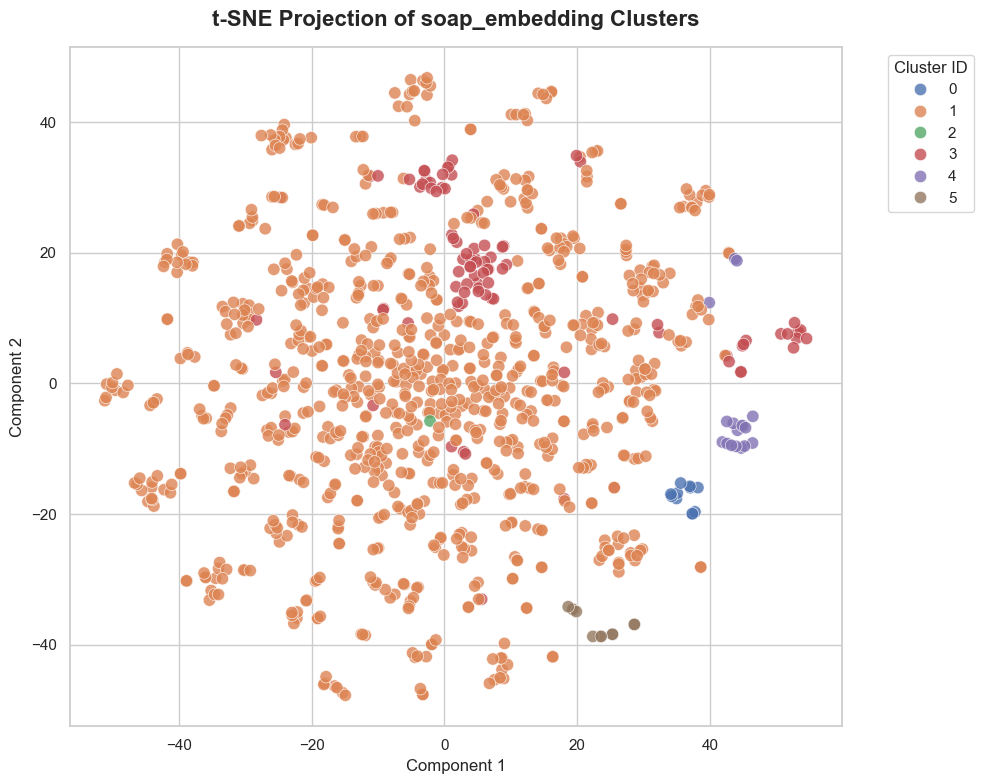

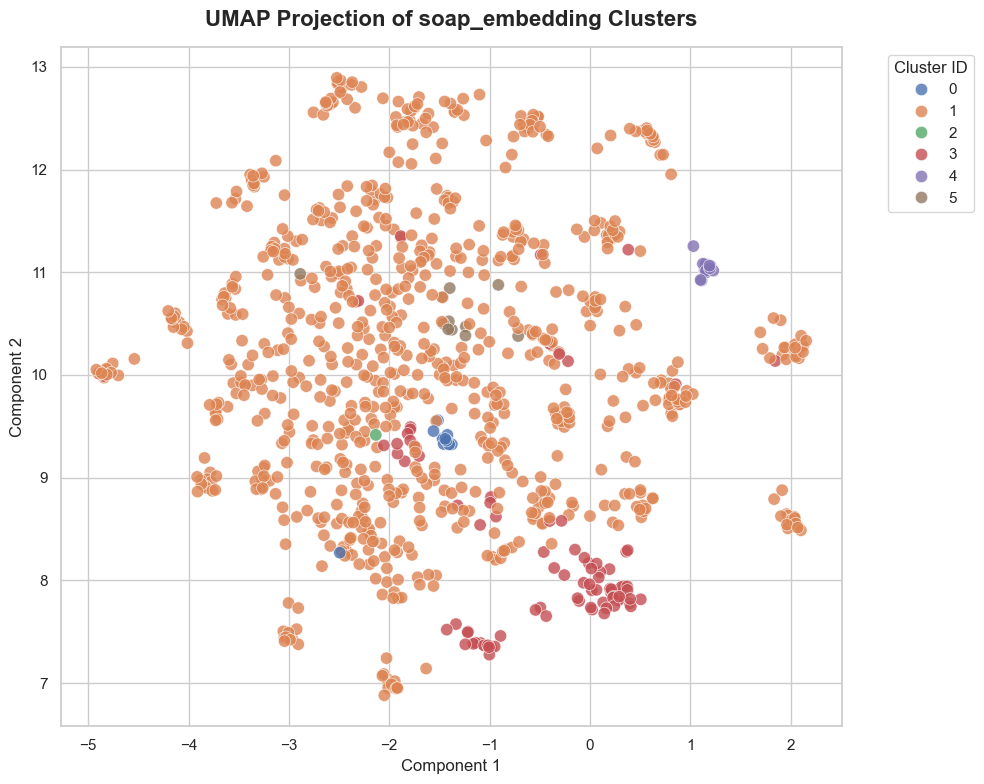

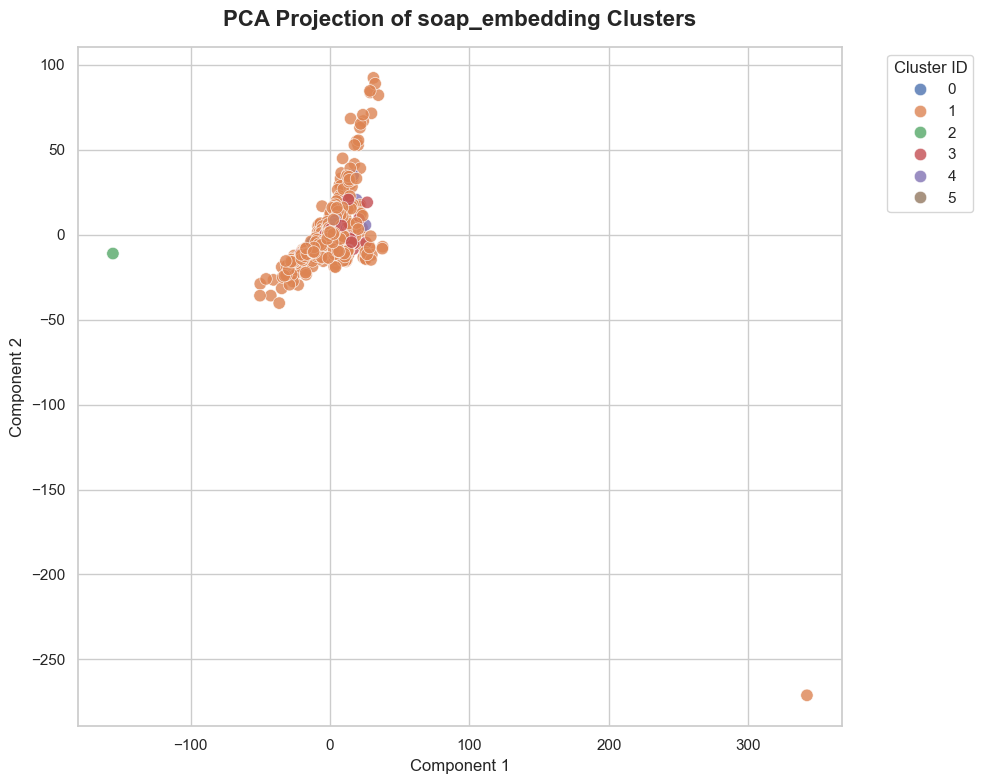

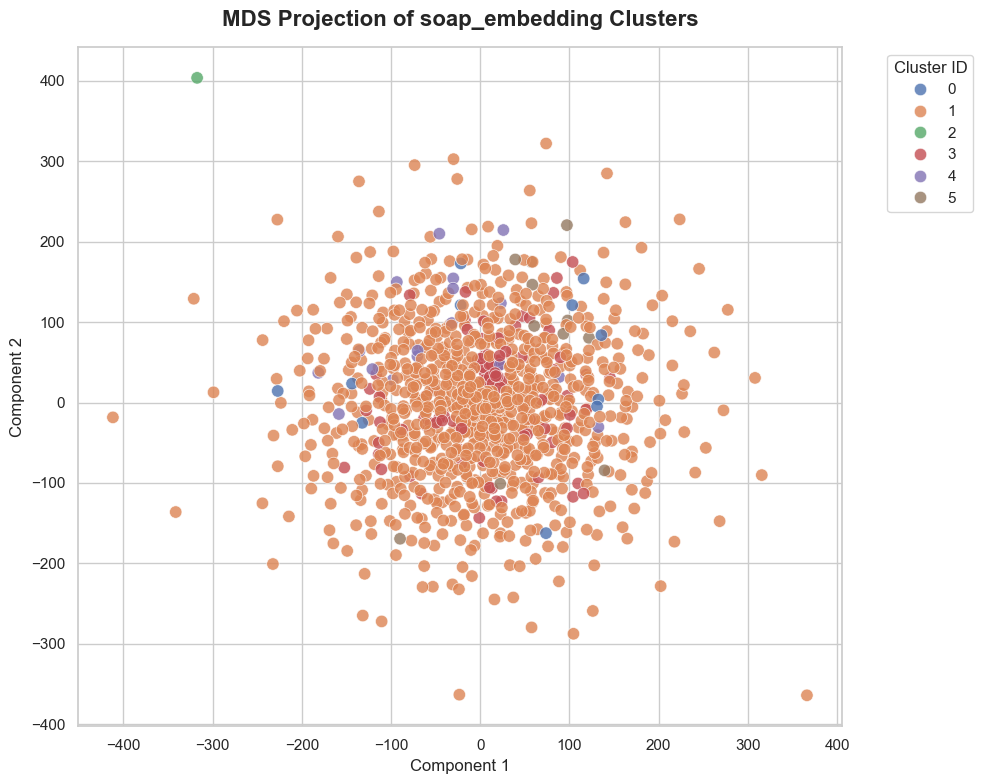

File saved to clustering_results.json.gz


In [20]:
output_filename = plot_chemiscope(mp.df, "soap_embedding", n_clusters=6)

In [21]:
chemiscope.show_input(output_filename)

<ChemiscopeWidget(meta={'name': 'SOAP_EMBEDDING Clustering', 'description': 'KMeans (k=...}, settings={'map': …

Number of molecules in cluster 1: 1
Number of molecules in cluster 2: 53
Number of molecules in cluster 3: 1
Number of molecules in cluster 4: 1
Number of molecules in cluster 5: 940
Number of molecules in cluster 6: 2
Number of molecules in cluster 7: 1
Number of molecules in cluster 8: 1


/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning:

The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning:

The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.



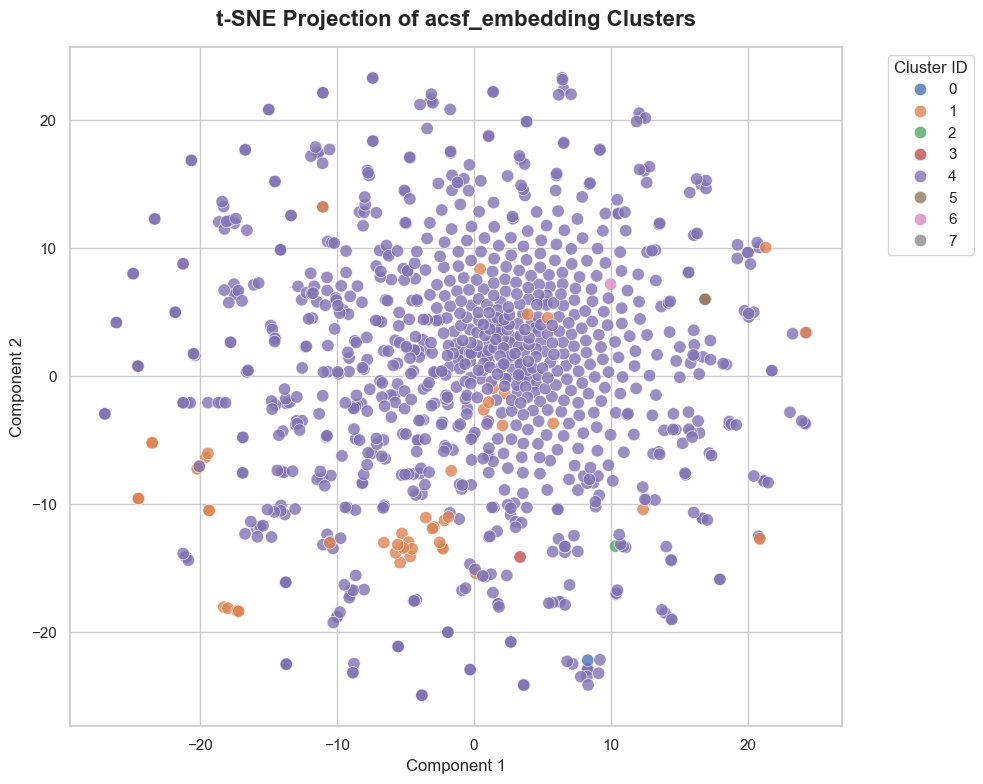

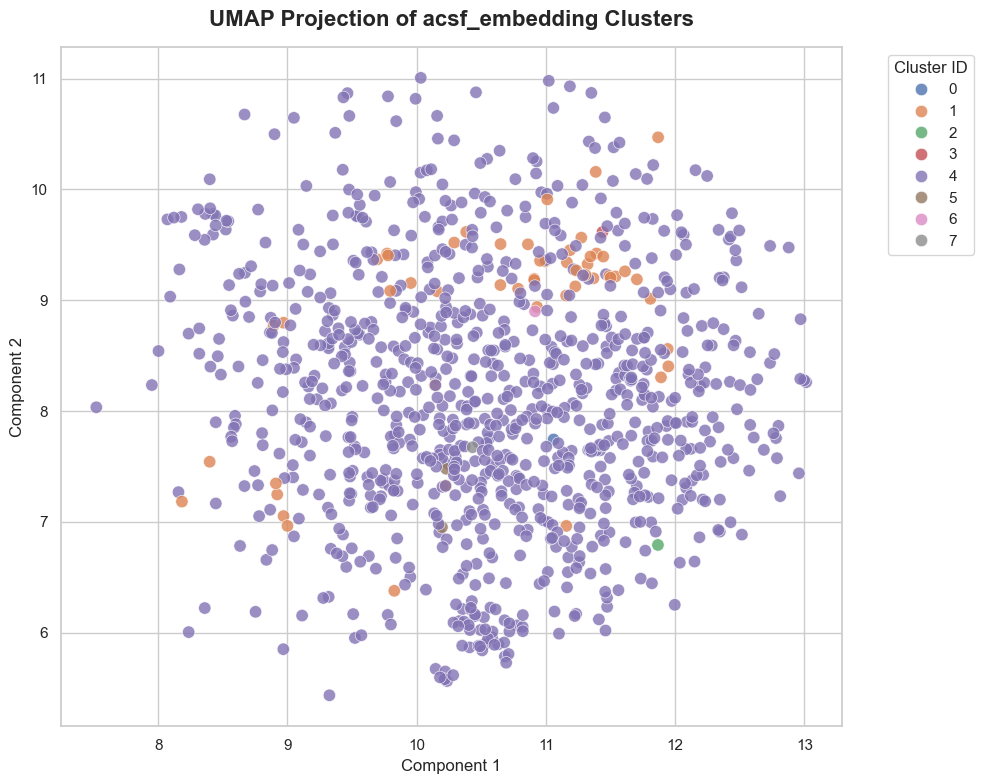

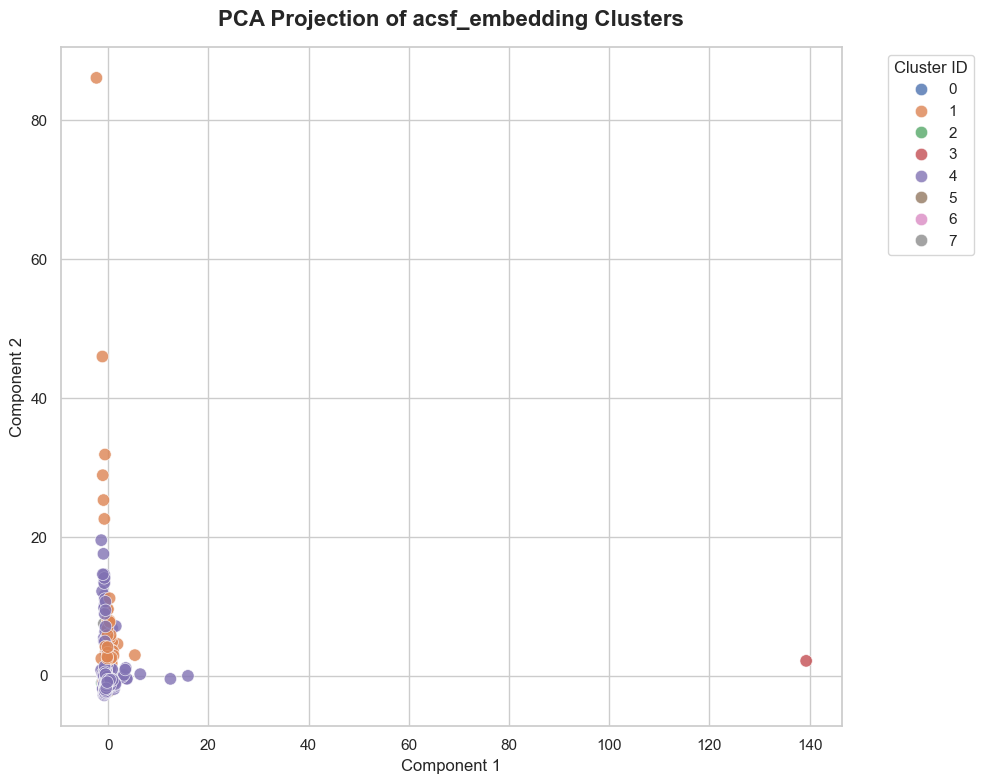

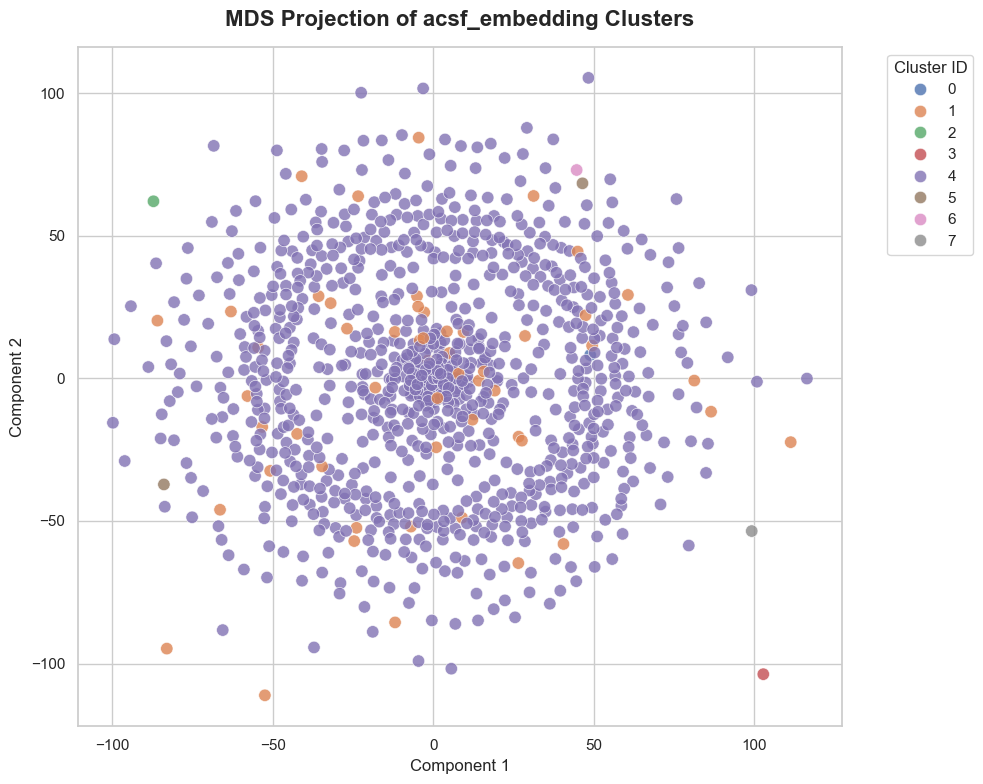

File saved to clustering_results.json.gz


In [28]:
output_path = plot_chemiscope(mp.df, "acsf_embedding", n_clusters=8)

In [29]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'ACSF_EMBEDDING Clustering', 'description': 'KMeans (k=...}, settings={'map': …

Analyzing 1000 materials...
Feature Matrix Shape: (1000, 11046)
--- Running KMEANS ---


2026-03-10 14:05:38.611 | INFO     | src.clusters:plot_tsne:417 - Reducing dimensions from 11046 to 50 via PCA before t-SNE...


Found 7 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0335
Silhouette Score: 0.1493
Calinski-Harabasz Score: 125.3583
Generating t-SNE plot...
--- Running t-SNE (Perplexity=30)... ---
Generating interactive TSNE plot...


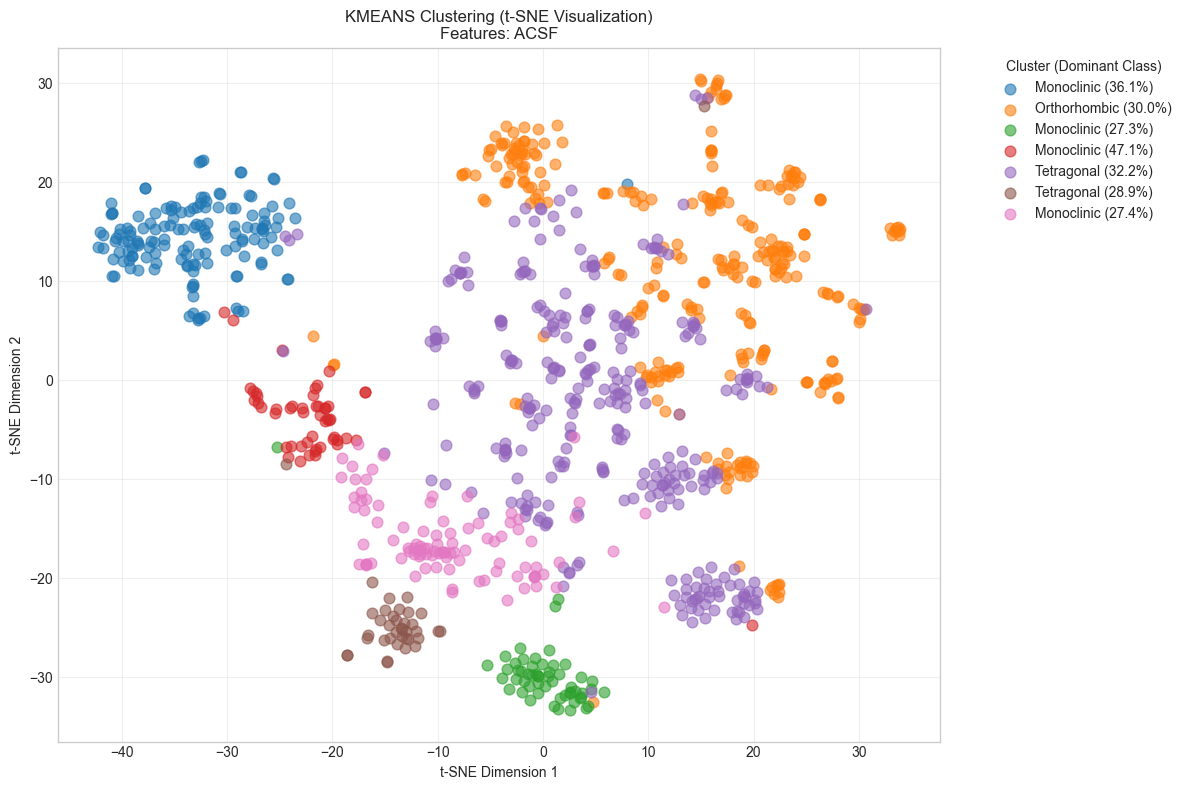

In [9]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


def analyze_materials_project(df):
    df_clean = df.drop_nulls(subset=["acsf_embedding"])
    
    if df_clean.height == 0:
        print("No valid embeddings found. Did you run with force_fetch=True?")
        return

    print(f"Analyzing {df_clean.height} materials...")

    #soap_matrix = np.array(df_clean["soap_embedding"].to_list())
    acsf_matrix = np.array(df_clean["acsf_embedding"].to_list())
    
    # Standardize them separately first (important because they have different scales)
    scaler_soap = StandardScaler()
    scaler_acsf = StandardScaler()
    
    #soap_scaled = scaler_soap.fit_transform(soap_matrix)
    acsf_scaled = scaler_acsf.fit_transform(acsf_matrix)
    
    # Concatenate: X = [SOAP_normalized | ACSF_normalized]
    #X_combined = np.hstack([soap_scaled, acsf_scaled])
    
    print(f"Feature Matrix Shape: {acsf_matrix.shape}")

    # 4. Define 'True Labels' for coloring (Optional)
    # Using 'crystal_system' (Cubic, Hexagonal, etc.) is great for validation
    true_labels = df_clean["crystal_system"].to_list()
    
    # Create Metadata DataFrame for hovering in interactive plots
    meta_df = df_clean.select([
        pl.col("material_id").alias("mol_id"), # Renaming to match ClusterAnalysis expectations
        pl.col("formula_pretty").alias("canonical_smiles"), # Using formula as 'SMILES'
        "crystal_system",
        "space_group"
    ])

    # 5. Run Clustering Analysis
    analyzer = ClusterAnalysis(acsf_matrix, true_labels=true_labels, meta_df=meta_df)
    
    # Run K-Means
    # n_clusters=7 is a good starting guess for crystal systems (7 systems)
    analyzer.run(method='kmeans', n_clusters=7)
    
    # Evaluate
    analyzer.evaluate()

    # 6. Plot t-SNE
    print("Generating t-SNE plot...")
    analyzer.plot_tsne(
        perplexity=30, 
        title_suffix="Features: ACSF", 
        highlight_top_overlaps=0 # Turn off if you don't want overlap circles
    )
    
    # Optional: Interactive Plot
    analyzer.plot_interactive(method='tsne', perplexity=30)

analyze_materials_project(mp.df)

# Mahalanobis Distances

In [10]:
X = np.array(mp.df["acsf_embedding"].to_list())
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
labels = gmm.fit_predict(X)
probs = gmm.predict_proba(X)

KeyboardInterrupt: 

Pre-processing and running t-SNE...


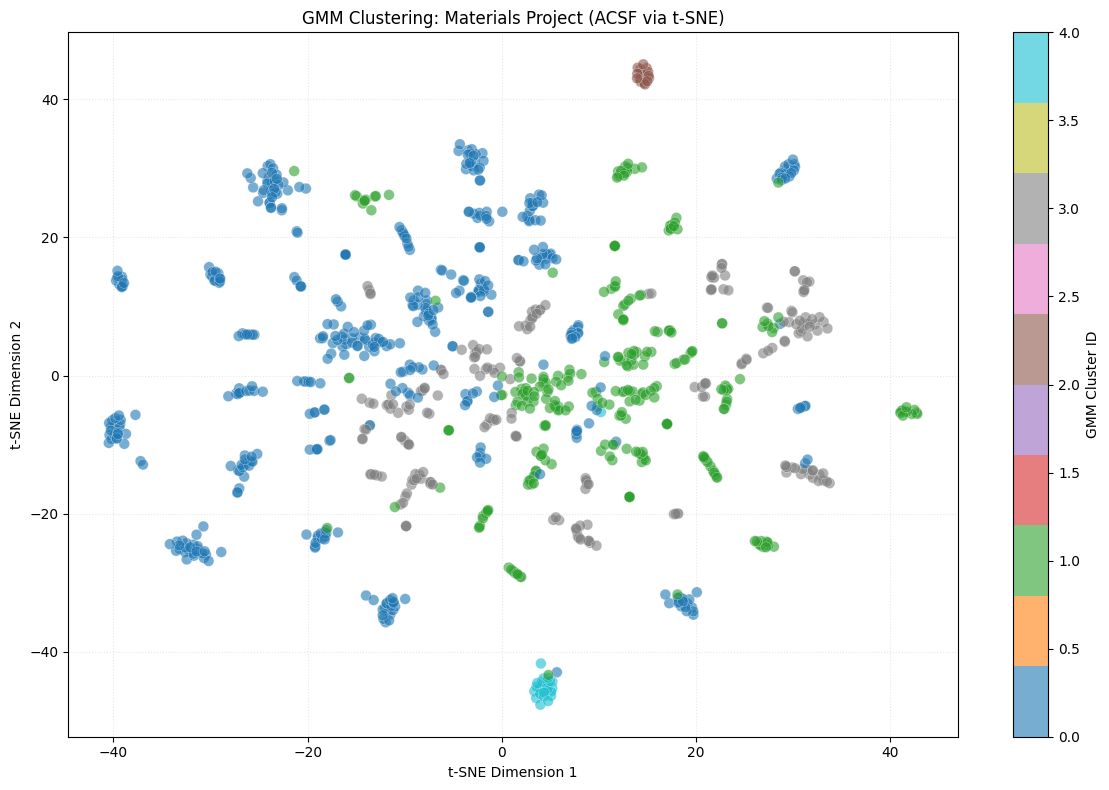

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def plot_materials_gmm_tsne(X, labels, probs, perplexity=30, title="GMM Clustering: Materials Project (ACSF via t-SNE)"):
    """
    Plots GMM results using t-SNE for better local cluster separation.
    """
    print("Pre-processing and running t-SNE...")
    
    # 1. Scale features (Required for t-SNE to perform well)
    X_scaled = StandardScaler().fit_transform(X)
    
    # 2. PCA Pre-reduction (Speeds up t-SNE and reduces noise)
    # We reduce to 50 components before running t-SNE
    if X_scaled.shape[1] > 50:
        X_pca = PCA(n_components=50).fit_transform(X_scaled)
    else:
        X_pca = X_scaled

    # 3. Run t-SNE
    tsne = TSNE(
        n_components=2, 
        perplexity=perplexity, 
        init='pca', 
        learning_rate='auto', 
        random_state=42
    )
    X_tsne = tsne.fit_transform(X_pca)
    
    # 4. Calculate Confidence for visualization
    confidence = np.max(probs, axis=1)
    
    # 5. Create Plot
    plt.figure(figsize=(12, 8))
    
    # c=labels: color by GMM cluster
    # alpha & s: scale by GMM probability (confidence)
    scatter = plt.scatter(
        X_tsne[:, 0], 
        X_tsne[:, 1], 
        c=labels, 
        cmap='tab10',  # Distinct colors for clusters
        alpha=0.6, 
        s=confidence * 60,
        edgecolors='white',
        linewidth=0.3
    )
    
    # 6. Formatting
    cb = plt.colorbar(scatter)
    cb.set_label('GMM Cluster ID')
    
    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, linestyle=':', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
# X = np.array(mp.df["acsf_embedding"].to_list())
# labels = gmm.fit_predict(X)
# probs = gmm.predict_proba(X)
plot_materials_gmm_tsne(X, labels, probs, perplexity=30)

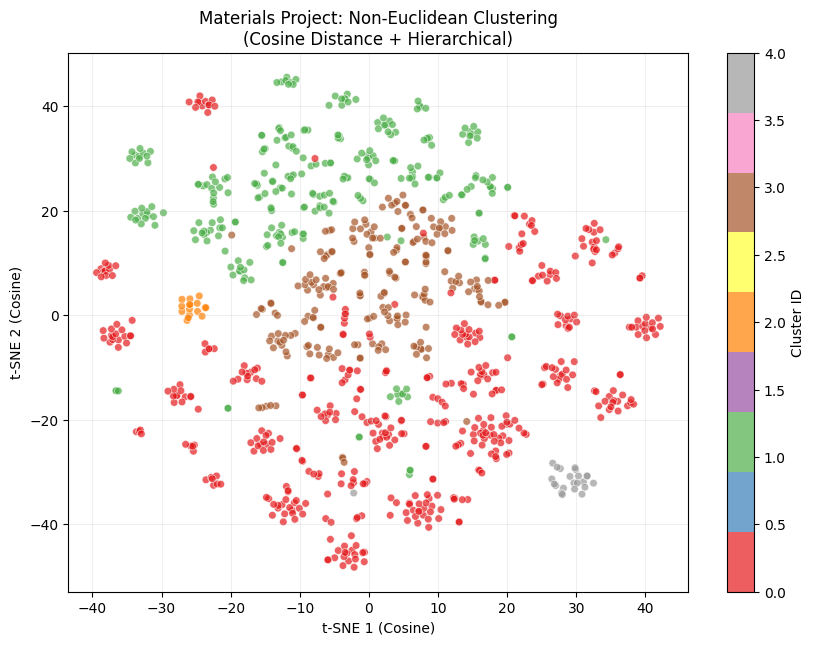

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_distances
from sklearn.manifold import TSNE

# 1. Prepare Data
# ACSF vectors often benefit from scaling before distance calculation
X = np.array(mp.df["acsf_embedding"].to_list())
X_scaled = StandardScaler().fit_transform(X)

# 2. Clustering with Cosine Distance
# 'average' linkage works well with cosine distance
cluster_model = AgglomerativeClustering(
    n_clusters=5, 
    metric='cosine', 
    linkage='average'
)
labels = cluster_model.fit_predict(X_scaled)

# 3. Visualization using t-SNE
# Note: We tell t-SNE to also use cosine metric so the plot matches the clustering logic
tsne = TSNE(
    n_components=2, 
    metric='cosine', 
    init='random', 
    perplexity=30, 
    random_state=42
)
X_embedded = tsne.fit_transform(X_scaled)

# 4. Plotting
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_embedded[:, 0], 
    X_embedded[:, 1], 
    c=labels, 
    cmap='Set1', 
    alpha=0.7, 
    s=30,
    edgecolors='white',
    linewidth=0.5
)

plt.colorbar(scatter, label='Cluster ID')
plt.title("Materials Project: Non-Euclidean Clustering\n(Cosine Distance + Hierarchical)")
plt.xlabel("t-SNE 1 (Cosine)")
plt.ylabel("t-SNE 2 (Cosine)")
plt.grid(True, alpha=0.2)
plt.show()